In [57]:
# If neccesary install once:
#!pip install numpy pandas matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from energymap4py import data_access as em_data
from applications import heatLoadModel as hlm
from pathlib import Path

## Weather file (Energy Plus format epw)

A Berlin weather data set of the year 2025 is used for all following calculations.

In [58]:
weather = hlm.read_epw_weather(
    epw_file = Path("./applications/HOSTRADA_Berlin2025.epw"),
    reset_index_to_continuous_year=True)

## Impact of building parameters on the heat load profile

### Thermal building capacity

The thermal capacity of the building is set to "light", "medium" and "heavy":

https://energymap-berlin.de/map/query?mode=uuid&uuid=DEBE04YY500002vO
https://energymap-berlin.de/map/query?mode=modeldefault&uuids=DEBE04YY500002vO
Yearly heat demand: 2201861.42 kWh/a


<function matplotlib.pyplot.show(close=None, block=None)>

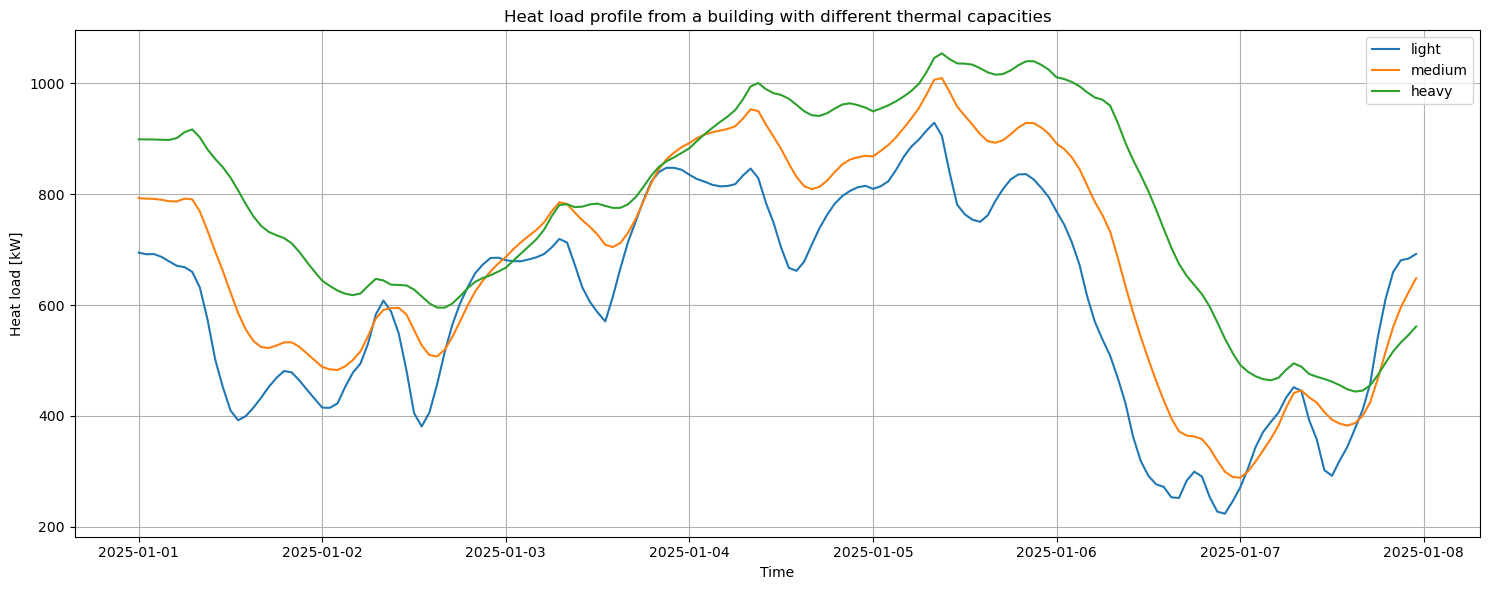

In [74]:
data = em_data.by_uuid('DEBE04YY500002vO', added_details=True)
annual_energy_demand = float(data[0]['cons_c1r1'])
print('Yearly heat demand:',annual_energy_demand,'kWh/a')
heated_floor_area = float(data[0]['heated_area'])
surface_volume_ratio=float(data[0]['surface_area_to_volume_ratio'])
window_area_fraction=float(data[0]['outwalls_window_ratio'])
period = slice("2025-01-01 00:00", "2025-01-07 23:00")

loads = []
for capacity in ["light","medium","heavy"]:
    load = hlm.calculate_hourly_heat_load_advanced(
            annual_energy_kwh=annual_energy_demand,
            outdoor_temp_C=weather["T_a"],
            global_irradiance_W_m2=weather["GHI"],
            heated_floor_area_m2=heated_floor_area,
            surface_volume_ratio_m_inv=surface_volume_ratio,
            window_area_fraction=window_area_fraction,
            thermal_capacity=capacity,
            dhw_specific_kwh_m2a=12.5,
            use_random_user_behavior=False,
            random_seed=42,
            behavior_strength=1.0,
            use_night_setback=False,
        )
    loads.append(load.loc[period])

plt.figure(figsize=(15, 6))
plt.plot(loads[0].index, loads[0]["total_heat_load_kW"], label="light")
plt.plot(loads[1].index, loads[1]["total_heat_load_kW"], label="medium")
plt.plot(loads[2].index, loads[2]["total_heat_load_kW"], label="heavy")
plt.title("Heat load profile from a building with different thermal capacities")
plt.xlabel("Time")
plt.ylabel("Heat load [kW]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show

### Nighttime temperature reduction

The night time set temperature is set to 18 °C, 16 °C and 14 °C:

https://energymap-berlin.de/map/query?mode=uuid&uuid=DEBE04YY500002vO
https://energymap-berlin.de/map/query?mode=modeldefault&uuids=DEBE04YY500002vO
Yearly heat demand: 2201861.42 kWh/a


<function matplotlib.pyplot.show(close=None, block=None)>

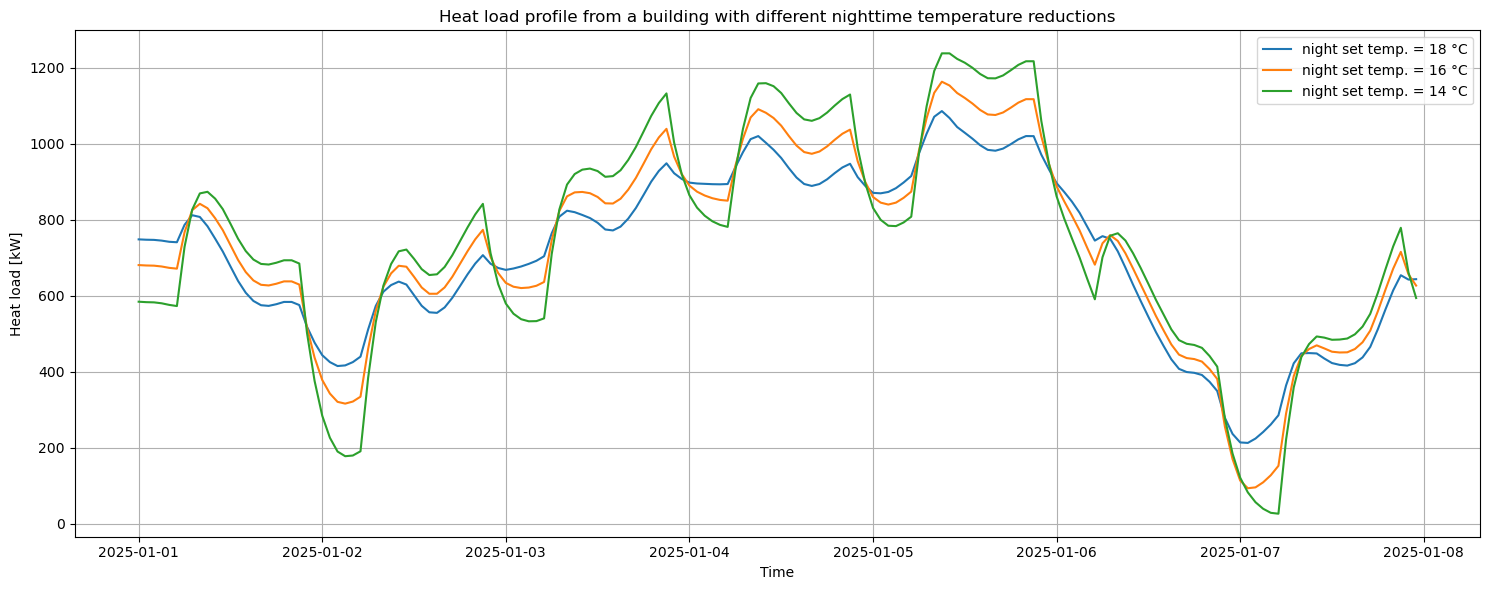

In [75]:
data = em_data.by_uuid('DEBE04YY500002vO', added_details=True)
annual_energy_demand = float(data[0]['cons_c1r1'])
print('Yearly heat demand:',annual_energy_demand,'kWh/a')
heated_floor_area = float(data[0]['heated_area'])
surface_volume_ratio=float(data[0]['surface_area_to_volume_ratio'])
window_area_fraction=float(data[0]['outwalls_window_ratio'])
period = slice("2025-01-01 00:00", "2025-01-07 23:00")

loads = []
for night_setback_room_temp_C in [18,16,14]:
    load = hlm.calculate_hourly_heat_load_advanced(
            annual_energy_kwh=annual_energy_demand,
            outdoor_temp_C=weather["T_a"],
            global_irradiance_W_m2=weather["GHI"],
            heated_floor_area_m2=heated_floor_area,
            surface_volume_ratio_m_inv=surface_volume_ratio,
            window_area_fraction=window_area_fraction,
            thermal_capacity="medium",
            dhw_specific_kwh_m2a=12.5,
            use_random_user_behavior=False,
            random_seed=42,
            behavior_strength=1.0,
            use_night_setback=True,
            night_setback_room_temp_C = night_setback_room_temp_C,
        )
    loads.append(load.loc[period])

plt.figure(figsize=(15, 6))
plt.plot(loads[0].index, loads[0]["total_heat_load_kW"], label="night set temp. = 18 °C")
plt.plot(loads[1].index, loads[1]["total_heat_load_kW"], label="night set temp. = 16 °C")
plt.plot(loads[2].index, loads[2]["total_heat_load_kW"], label="night set temp. = 14 °C")
plt.title("Heat load profile from a building with different nighttime temperature reductions")
plt.xlabel("Time")
plt.ylabel("Heat load [kW]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show

## Statistical User Behavior

Different building users show a different user behaviour: 

https://energymap-berlin.de/map/query?mode=uuid&uuid=DEBE04YY500002vO
https://energymap-berlin.de/map/query?mode=modeldefault&uuids=DEBE04YY500002vO
Yearly heat demand: 2201861.42 kWh/a


<function matplotlib.pyplot.show(close=None, block=None)>

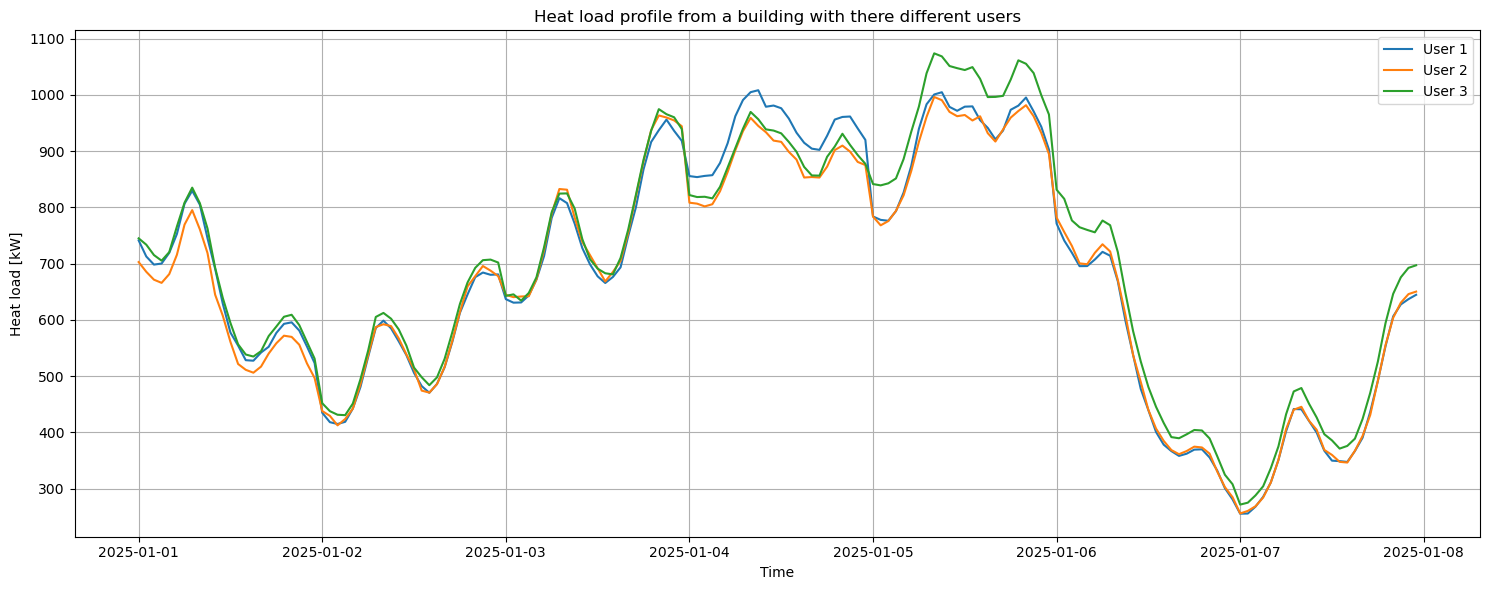

In [76]:
data = em_data.by_uuid('DEBE04YY500002vO', added_details=True)
annual_energy_demand = float(data[0]['cons_c1r1'])
print('Yearly heat demand:',annual_energy_demand,'kWh/a')
heated_floor_area = float(data[0]['heated_area'])
surface_volume_ratio=float(data[0]['surface_area_to_volume_ratio'])
window_area_fraction=float(data[0]['outwalls_window_ratio'])
period = slice("2025-01-01 00:00", "2025-01-07 23:00")

loads = []
for random_seed in [42,65,50]:
    load = hlm.calculate_hourly_heat_load_advanced(
            annual_energy_kwh=annual_energy_demand,
            outdoor_temp_C=weather["T_a"],
            global_irradiance_W_m2=weather["GHI"],
            heated_floor_area_m2=heated_floor_area,
            surface_volume_ratio_m_inv=surface_volume_ratio,
            window_area_fraction=window_area_fraction,
            thermal_capacity="medium",
            dhw_specific_kwh_m2a=12.5,
            use_random_user_behavior=True,
            random_seed=random_seed,
            behavior_strength=1.0,
            use_night_setback=use_night_setback,
        )
    loads.append(load.loc[period])

plt.figure(figsize=(15, 6))
plt.plot(loads[0].index, loads[0]["total_heat_load_kW"], label="User 1")
plt.plot(loads[1].index, loads[1]["total_heat_load_kW"], label="User 2")
plt.plot(loads[2].index, loads[2]["total_heat_load_kW"], label="User 3")
plt.title("Heat load profile from a building with there different users")
plt.xlabel("Time")
plt.ylabel("Heat load [kW]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show

## Yearly heat load Profile of a single building

Generating an hourly heating load profile for a single building. The building data (annual heating demand and building characteristics) are retrieved from the EnergyMap Berlin database using the building’s UUID, and the necessary weather data (outdoor air temperature and global radiation) are obtained from a weather data file in EnergyPlus format (epw) for the Berlin Alexanderplatz location for the climate year 2025.   

https://energymap-berlin.de/map/query?mode=uuid&uuid=DEBE04YY500002vO
https://energymap-berlin.de/map/query?mode=modeldefault&uuids=DEBE04YY500002vO
Year of construction: 1962
Heritage type: Baudenkmal
Building ground area: 4449.4 m2
Yearly heat demand: 2201861.42 kWh/a
Heated area: 10284.3090909091 m2
Surface to volume ratio: 0.280572561554495 1/m


<function matplotlib.pyplot.show(close=None, block=None)>

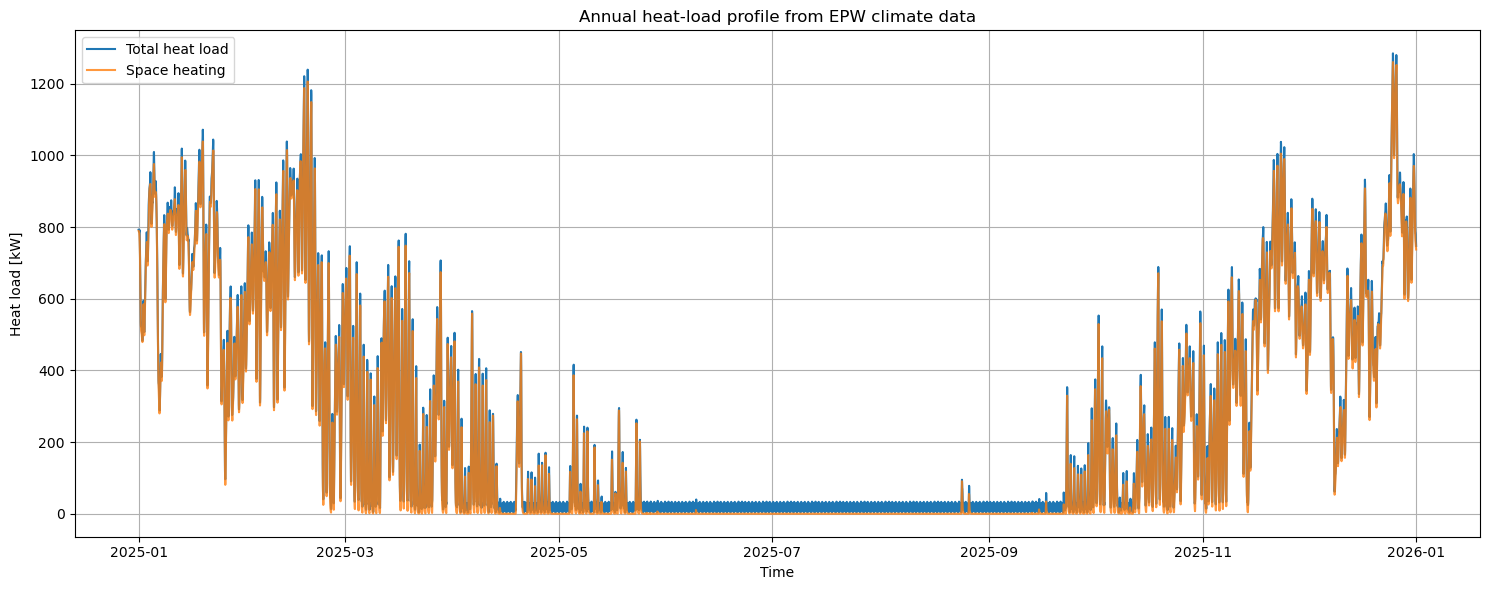

In [77]:
data = em_data.by_uuid('DEBE04YY500002vO', added_details=True)
print('Year of construction:',data[0]['year_of_construction'])
print('Heritage type:',data[0]['heritage_type'])
print('Building ground area:',data[0]['ground_area'],'m2')
print('Yearly heat demand:',data[0]['cons_c1r1'],'kWh/a')
print('Heated area:',data[0]['heated_area'],'m2')
print('Surface to volume ratio:', data[0]['surface_area_to_volume_ratio'], '1/m')

annual_energy_demand = float(data[0]['cons_c1r1'])
heated_floor_area = float(data[0]['heated_area'])
surface_volume_ratio=float(data[0]['surface_area_to_volume_ratio'])
window_area_fraction=float(data[0]['outwalls_window_ratio'])

load = hlm.calculate_hourly_heat_load_advanced(
        annual_energy_kwh=annual_energy_demand,
        outdoor_temp_C=weather["T_a"],
        global_irradiance_W_m2=weather["GHI"],
        heated_floor_area_m2=heated_floor_area,
        surface_volume_ratio_m_inv=surface_volume_ratio,
        window_area_fraction=window_area_fraction,
        thermal_capacity="medium",
        dhw_specific_kwh_m2a=12.5,
        use_random_user_behavior=False,
        random_seed=42,
        behavior_strength=1.0,
        use_night_setback=False,
    )
load.to_csv("heatingLoad.csv", index=True)

plt.figure(figsize=(15, 6))
plt.plot(load.index, load["total_heat_load_kW"], label="Total heat load")
plt.plot(load.index, load["space_heating_load_kW"], label="Space heating", alpha=0.8)
plt.title("Annual heat-load profile from EPW climate data")
plt.xlabel("Time")
plt.ylabel("Heat load [kW]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show

## Annual duration line of the heat load of a single building

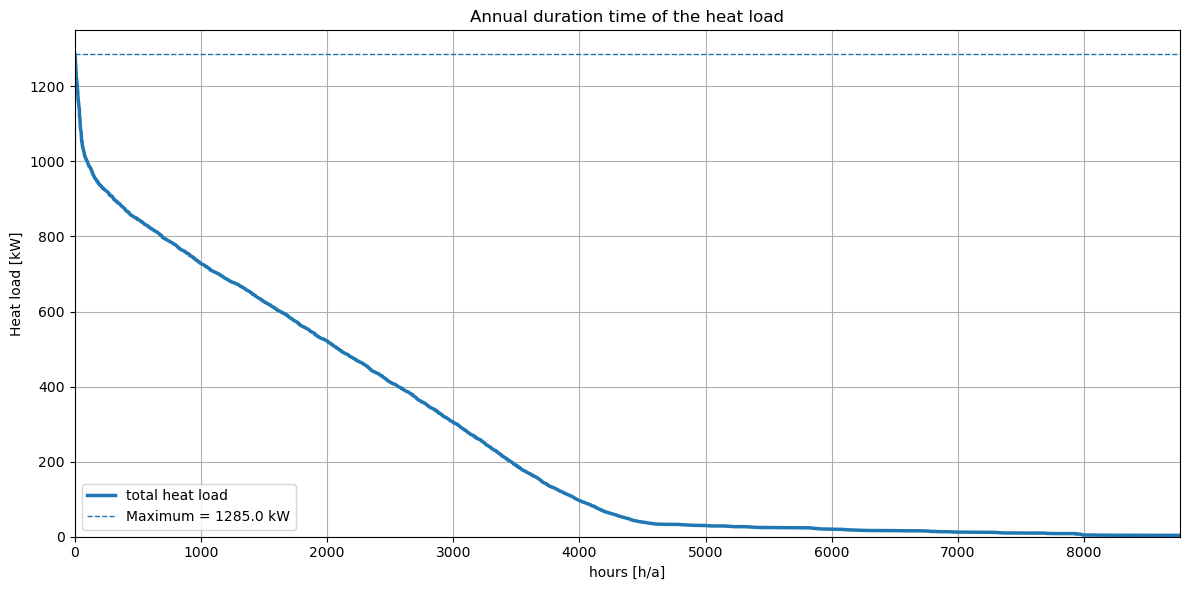

In [78]:
duration_sum = (
    load["total_heat_load_kW"]
    .dropna()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

hours = np.arange(1, len(duration_sum) + 1)

max_load = duration_sum.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(
    hours,
    duration_sum,
    label = "total heat load",
    linewidth=2.5
)

plt.axhline(
    y=max_load,
    linestyle="--",
    linewidth=1,
    label=f"Maximum = {max_load:.1f} kW"
)
plt.title("Annual duration time of the heat load")
plt.xlabel("hours [h/a]")
plt.ylabel("Heat load [kW]")
plt.xlim(0, len(duration_sum))
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Heat load profiles for a couple of buildings

Generating an hourly heating load profile for a group of buildings for the first week of the year 2025. The building data (annual heating demand and building characteristics) is retrieved from the EnergyMap Berlin database by specifying a polyline (all buildings to the right and left of the polyline within a 25-meter distance), and the necessary weather data (outdoor air temperature and global radiation) is obtained from a weather data file in EnergyPlus format (epw) for the Berlin Alexanderplatz location for the climate year 2025.    

https://energymap-berlin.de/map/query?mode=line&linestring=13.324412829321979,52.516957033745285,13.322429034685205,52.514576803927426,13.322485599381766,52.51321707446597&distance=25
https://energymap-berlin.de/map/query?mode=modeldefault&uuids=DEBE04YY50000ItM
https://energymap-berlin.de/map/query?mode=modeldefault&uuids=DEBE04YY500003mP
https://energymap-berlin.de/map/query?mode=modeldefault&uuids=DEBE04YY500006zG
https://energymap-berlin.de/map/query?mode=modeldefault&uuids=DEBE04YY500001Aj
4
Year of construction: 1961
Heritage type: None
Building ground area: 1359.2 m2
Yearly heat demand: 628458.90 kWh/a
Heated area: 2798.43966942149 m2
Surface to volume ratio: 0.429322602164023 1/m
 
Year of construction: 2011
Heritage type: None
Building ground area: 2842.6 m2
Yearly heat demand: 3102378.55 kWh/a
Heated area: 16008.2444444444 m2
Surface to volume ratio: 0.229138511961198 1/m
 
Year of construction: 1961
Heritage type: Baudenkmal
Building ground area: 1858.8 m2
Yearly heat demand

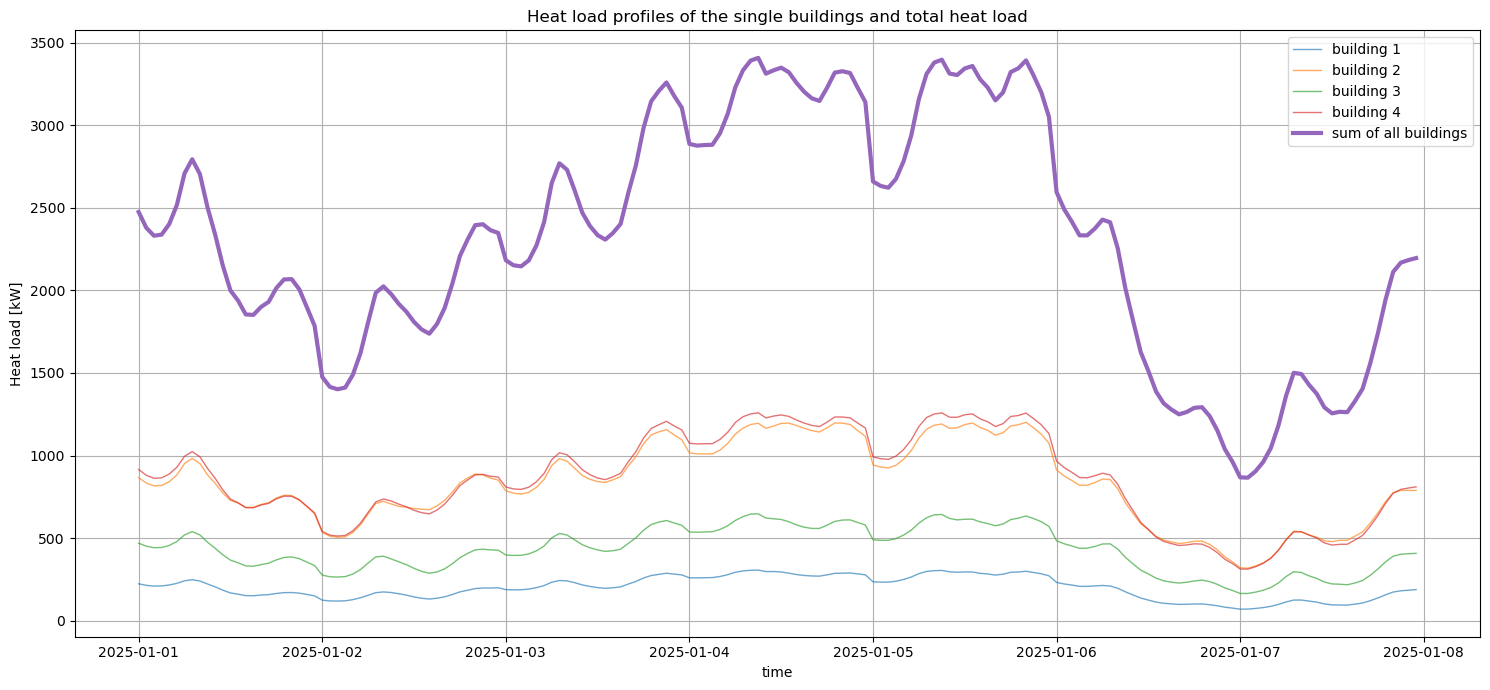

In [79]:
line = [(13.324412829321979, 52.516957033745285),
        (13.322429034685205, 52.514576803927426),
        (13.322485599381766, 52.51321707446597)]

data = em_data.by_line(line_points=line, added_details=True, dist=25)
print(len(data))

period = slice("2025-01-01 00:00", "2025-01-07 23:00")
loads = []

for i, d in enumerate(data):
    print('Year of construction:',d['year_of_construction'])
    print('Heritage type:',d['heritage_type'])
    print('Building ground area:',d['ground_area'],'m2')
    print('Yearly heat demand:',d['cons_c1r1'],'kWh/a')
    print('Heated area:',d['heated_area'],'m2')
    print('Surface to volume ratio:', d['surface_area_to_volume_ratio'], '1/m')
    print(' ')

    annual_energy = float(d['cons_c1r1'])
    heated_floor_area = float(d['heated_area'])
    surface_volume_ratio=float(d['surface_area_to_volume_ratio'])
    window_area_fraction=float(d['outwalls_window_ratio'])
    
    load = hlm.calculate_hourly_heat_load_advanced(
            annual_energy_kwh=annual_energy,
            outdoor_temp_C=weather["T_a"],
            global_irradiance_W_m2=weather["GHI"],
            heated_floor_area_m2=heated_floor_area,
            surface_volume_ratio_m_inv=surface_volume_ratio,
            window_area_fraction=window_area_fraction,
            thermal_capacity="medium",
            dhw_specific_kwh_m2a=12.5,
            use_random_user_behavior=True,
            random_seed=42,
            behavior_strength=1.0,
            use_night_setback=False)
    loads.append(load)

    load.index = pd.to_datetime(load.index)
    load_period = load.loc[period]

# Heating load of all buildings
building_loads = pd.concat(
    [
        load["total_heat_load_kW"].rename(f"building {i + 1}")
        for i, load in enumerate(loads)
    ],
    axis=1
)
building_loads["Sum"] = building_loads.sum(axis=1)
building_loads_period = building_loads.loc[period]

building_loads_period.to_csv("heatingLoads_period.csv", index=True)


plt.figure(figsize=(15, 7))

# Single buildings
for column in building_loads_period.columns.drop("Sum"):
    plt.plot(
        building_loads_period.index,
        building_loads_period[column],
        label=column,
        alpha=0.65,
        linewidth=1
    )

# Sum of all buildings
plt.plot(
    building_loads_period.index,
    building_loads_period["Sum"],
    label="sum of all buildings",
    linewidth=3
)

plt.title("Heat load profiles of the single buildings and total heat load")
plt.xlabel("time")
plt.ylabel("Heat load [kW]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()